In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

# List GPUs available
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

# Check if GPUs are available
if gpus:
    print("GPU is available.")
else:
    print("GPU is not available.")

# Set memory growth for each GPU
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2025-11-17 13:18:19.555835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763385499.744226      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763385499.798402      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.


In [2]:
import tensorflow as tf

In [3]:
!pip install -q segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.7 MB/s eta 0:00:00


In [4]:
!pip install -q patchify

In [5]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow.keras
import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [6]:
from patchify import patchify,unpatchify

In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Add, Activation, Multiply, Concatenate
from tensorflow.keras import Input,Model

In [8]:
# Residual Conv Block with skip connection
def conv_block(input, num_filter):
    # Store input for residual connection
    shortcut = input

    # First conv layer
    x = Conv2D(num_filter, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second conv layer
    x = Conv2D(num_filter, 3, padding="same")(x)
    x = BatchNormalization()(x)

    # Match dimensions for residual connection
    if input.shape[-1] != num_filter:
        shortcut = Conv2D(num_filter, 1, padding="same")(shortcut)

    # Add residual connection
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [9]:
# Encoder block with residual connections
def encoder_block(input, num_filter):
    x = conv_block(input, num_filter)
    p = MaxPooling2D((2, 2))(x)
    return x, p

In [10]:
# Attention Gate
def attention_gate(skip_feature, gating_signal, num_filter):
    """
    Attention gate to focus on relevant features from skip connections
    skip_feature: features from encoder (higher resolution)
    gating_signal: features from decoder (lower resolution, upsampled)
    """
    # Transform skip connection
    skip = Conv2D(num_filter, 1, padding="same")(skip_feature)
    skip = BatchNormalization()(skip)

    # Transform gating signal
    gate = Conv2D(num_filter, 1, padding="same")(gating_signal)
    gate = BatchNormalization()(gate)

    # Combine and apply activation
    combined = Add()([skip, gate])
    combined = Activation('relu')(combined)

    # Generate attention coefficients
    attention = Conv2D(1, 1, padding="same")(combined)
    attention = Activation('sigmoid')(attention)

    # Apply attention to skip features
    attended_features = Multiply()([skip_feature, attention])

    return attended_features

In [11]:
# Decoder block with attention gate
def decoder_block(input, skip_feature, num_filter):
    # Upsample
    x = Conv2DTranspose(num_filter, 2, strides=2, padding='same')(input)

    # Apply attention gate to skip features
    skip_feature = attention_gate(skip_feature, x, num_filter)

    # Concatenate with attended skip features
    x = Concatenate()([x, skip_feature])

    # Apply residual conv block
    x = conv_block(x, num_filter)

    return x

In [12]:
# Build Residual Attention U-Net
def build_residual_attention_unet(n_classes, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS, dropout_rate=0.3):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

    # Encoder with residual blocks and Dropout
    s1, p1 = encoder_block(inputs, 64)
    s1 = Dropout(dropout_rate)(s1)
    s2, p2 = encoder_block(p1, 128)
    s2 = Dropout(dropout_rate)(s2)
    s3, p3 = encoder_block(p2, 256)
    s3 = Dropout(dropout_rate)(s3)
    s4, p4 = encoder_block(p3, 512)
    s4 = Dropout(dropout_rate)(s4)

    # Bridge with residual block and Dropout
    b1 = conv_block(p4, 1024)
    b1 = Dropout(dropout_rate)(b1)

    # Decoder with attention gates, residual blocks, and Dropout
    d1 = decoder_block(b1, s4, 512)
    d1 = Dropout(dropout_rate)(d1)
    d2 = decoder_block(d1, s3, 256)
    d2 = Dropout(dropout_rate)(d2)
    d3 = decoder_block(d2, s2, 128)
    d3 = Dropout(dropout_rate)(d3)
    d4 = decoder_block(d3, s1, 64)
    d4 = Dropout(dropout_rate)(d4)


    # Output layer
    outputs = Conv2D(n_classes, 1, padding="same", activation="softmax")(d4)  # Multiclass segmentation

    model = Model(inputs, outputs, name="Residual-Attention-U-Net")
    return model

In [13]:
from keras.utils import normalize
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [14]:
path="/kaggle/input/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset"

In [15]:
image = []
def read_img(path):
    for i in range(1, 8):
        for j in range(1, 9):
            img_path = f"{path}/Tile {i}/images/image_part_00{j}.jpg"
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is not None:
                img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                image.append(img)
            else:
                print(f"Warning: Could not read image at {img_path}")

In [16]:
def read_msk(path):
    out = []
    for i in range(1, 8):
        for j in range(1, 9):
            p = f"{path}/Tile {i}/masks/image_part_00{j}.png"
            m = cv2.imread(p, cv2.IMREAD_COLOR)
            if m is not None:
                m = cv2.cvtColor(m, cv2.COLOR_BGR2RGB)
                out.append(m)
    return out

masks = read_msk(path)

In [17]:
images=read_img(path)

In [18]:
# if image:
#     print("Shape of each image in the list:")
#     for i, img in enumerate(image):
#         print(f"Image {i}: {img.shape}")
# else:
#     print("The 'image' list is empty.")

In [19]:
# if masks:
#     print("Shape of each mask in the list:")
#     for i, msk in enumerate(masks):
#         print(f"Mask {i}: {msk.shape}")
# else:
#     print("The 'masks' list is empty.")

In [20]:
resized_mask = [
    cv2.resize(m, ((m.shape[1]//256)*256, (m.shape[0]//256)*256), interpolation=cv2.INTER_NEAREST)
    for m in masks
]

In [21]:
resized_image=[]
if image:
    for img in image:
        img_res = cv2.resize(img, ((img.shape[1]//256)*256, (img.shape[0]//256)*256), interpolation=cv2.INTER_LINEAR)
        resized_image.append(img_res)

In [22]:
Building   = [60, 16, 152]
Land       = [132, 41, 246]
Road       = [110, 193, 228]
Vegetation = [254, 221, 58]
Water      = [226, 169, 41]
Unlabeled  = [155, 155, 155]

def rgb_to_label(msk):
    if msk.ndim == 2 or msk.shape[-1] == 1:
        return msk.astype(np.uint8)
    y = np.zeros(msk.shape[:2], dtype=np.uint8)
    y[np.all(msk == Unlabeled,  axis=-1)] = 0
    y[np.all(msk == Building,   axis=-1)] = 1
    y[np.all(msk == Land,       axis=-1)] = 2
    y[np.all(msk == Road,       axis=-1)] = 3
    y[np.all(msk == Vegetation, axis=-1)] = 4
    y[np.all(msk == Water,      axis=-1)] = 5
    return y

label_masks = [rgb_to_label(m) for m in resized_mask]

In [23]:
image_patches = []
label_patches = []
patch_size = 256

for img, lbl in zip(resized_image, label_masks):
    ip = patchify(img, (patch_size, patch_size, 3), step=160)
    lp = patchify(lbl, (patch_size, patch_size), step=160)
    for r in range(ip.shape[0]):
        for c in range(ip.shape[1]):
            image_patches.append(ip[r, c, 0])
            label_patches.append(lp[r, c])

label_patches = np.array(label_patches, dtype=np.int32)

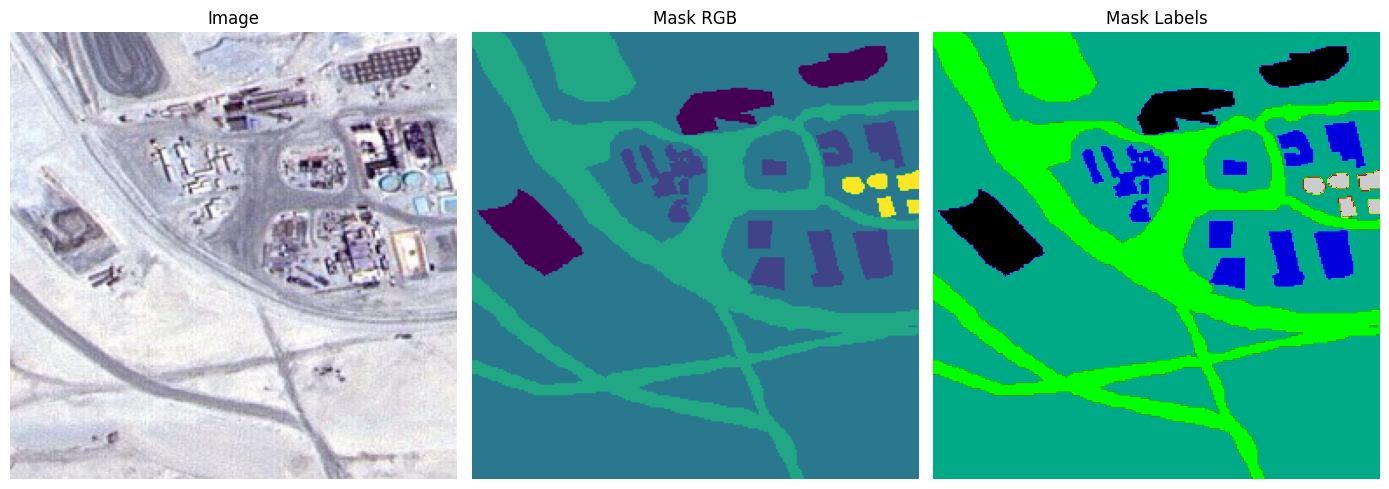

In [24]:
a=25
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image_patches[a])
axes[0].set_title("Image")
axes[0].axis('off')

axes[1].imshow(label_patches[a])
axes[1].set_title("Mask RGB")
axes[1].axis('off')

axes[2].imshow(rgb_to_label(label_patches[a]), cmap='nipy_spectral', vmin=0, vmax=5)
axes[2].set_title("Mask Labels")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [25]:
n_classes = len(np.unique(label_patches))
n_classes

6

In [26]:
np.unique(label_patches)

array([0, 1, 2, 3, 4, 5], dtype=int32)

In [27]:
#encoding
from keras.utils import to_categorical
labels_cat = to_categorical(label_patches, num_classes=n_classes)

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(image_patches, labels_cat, test_size=0.25, random_state=42)

# Convert lists to numpy arrays
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Normalize x data and ensure all data is float32
x_train = np.array(x_train, dtype=np.float32) / 255.0
x_test = np.array(x_test, dtype=np.float32) / 255.0
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [29]:
import tensorflow.keras.backend as K

def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

In [30]:
cls_counts = np.bincount(label_patches.reshape(-1), minlength=6)
freq = cls_counts / np.maximum(1, cls_counts.sum())
cw = 1.0 / np.sqrt(freq + 1e-6)
cw = cw / cw.sum()
cw = cw.astype(np.float32)
dice_loss = sm.losses.DiceLoss(class_weights=cw)
focal_loss = sm.losses.CategoricalFocalLoss()
def masked_total_loss(y_true, y_pred):
    mask = tf.not_equal(tf.argmax(y_true, axis=-1), 0)
    mask = tf.cast(mask, tf.float32)
    loss = 0.5*dice_loss(y_true, y_pred) + 0.5*focal_loss(y_true, y_pred)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-6)

In [31]:
IMG_HEIGHT = x_train.shape[1]
IMG_WIDTH  = x_train.shape[2]
IMG_CHANNELS = x_train.shape[3]

In [32]:
def get_model():
  return build_residual_attention_unet(n_classes, IMG_HEIGHT,IMG_WIDTH, IMG_CHANNELS)

In [33]:
model=get_model()
model.compile(optimizer=Adam(8e-6),
              loss=masked_total_loss,
              metrics=[sm.metrics.IOUScore(per_image=False, threshold=None),
                       sm.metrics.FScore(beta=1, threshold=None),
                       'accuracy'])
#model.summary()

I0000 00:00:1763385550.932046      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [34]:
callbacks = [
    EarlyStopping(monitor='val_loss',
                  patience=20,
                  verbose=1,
                  restore_best_weights=True)
]

In [35]:
history = model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test, y_test),
    epochs=200,
    batch_size=10,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/200


I0000 00:00:1763385587.840478     118 service.cc:148] XLA service 0x7d78a4029280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763385587.841518     118 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763385590.457478     118 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1763385595.709096     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763385595.943676     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763385596.669278     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763385596.9270

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.2522 - f1-score: 0.1490 - iou_score: 0.0848 - loss: 0.5293

E0000 00:00:1763385677.838159     116 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763385678.072636     116 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


117/117 ━━━━━━━━━━━━━━━━━━━━ 125s 447ms/step - accuracy: 0.2531 - f1-score: 0.1493 - iou_score: 0.0850 - loss: 0.5293 - val_accuracy: 0.5709 - val_f1-score: 0.1394 - val_iou_score: 0.0796 - val_loss: 0.5161
Epoch 2/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 45s 385ms/step - accuracy: 0.5874 - f1-score: 0.2855 - iou_score: 0.1848 - loss: 0.5072 - val_accuracy: 0.5802 - val_f1-score: 0.1772 - val_iou_score: 0.1136 - val_loss: 0.5118
Epoch 3/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 45s 386ms/step - accuracy: 0.6754 - f1-score: 0.3375 - iou_score: 0.2306 - loss: 0.5018 - val_accuracy: 0.6154 - val_f1-score: 0.2160 - val_iou_score: 0.1489 - val_loss: 0.5100
Epoch 4/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 45s 386ms/step - accuracy: 0.7030 - f1-score: 0.3728 - iou_score: 0.2631 - loss: 0.4987 - val_accuracy: 0.6161 - val_f1-score: 0.2478 - val_iou_score: 0.1743 - val_loss: 0.5079
Epoch 5/200
117/117 ━━━━━━━━━━━━━━━━━━━━ 45s 386ms/step - accuracy: 0.7362 - f1-score: 0.3972 - iou_score: 0.2860 - loss: 0.4964 - val_accu

In [36]:
y_pred=model.predict(x_test)

12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step

E0000 00:00:1763394684.514168     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763394684.747333     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763394685.355320     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763394685.611899     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1763394689.157162     118 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step 


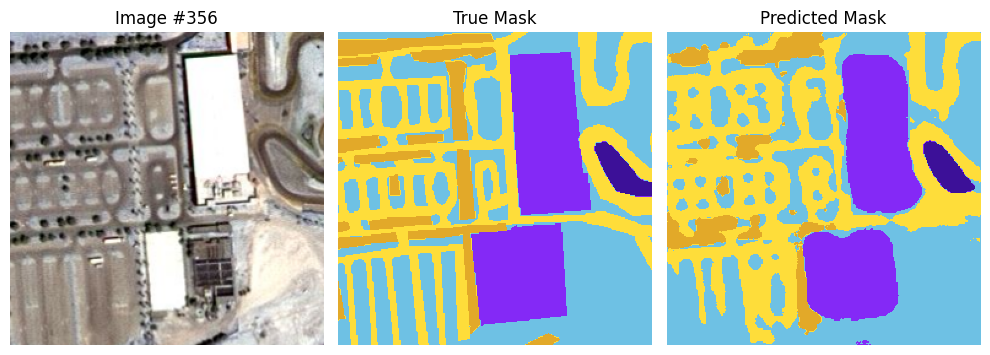

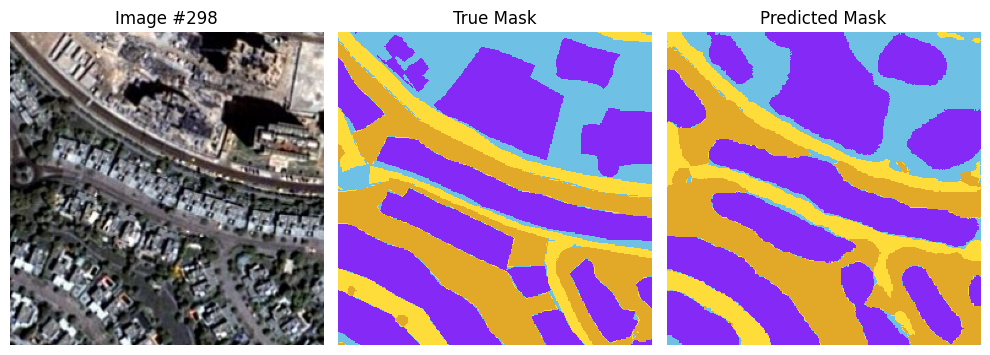

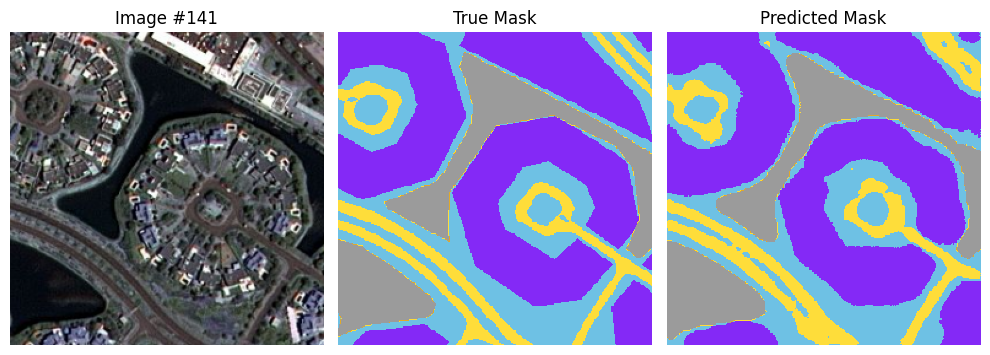

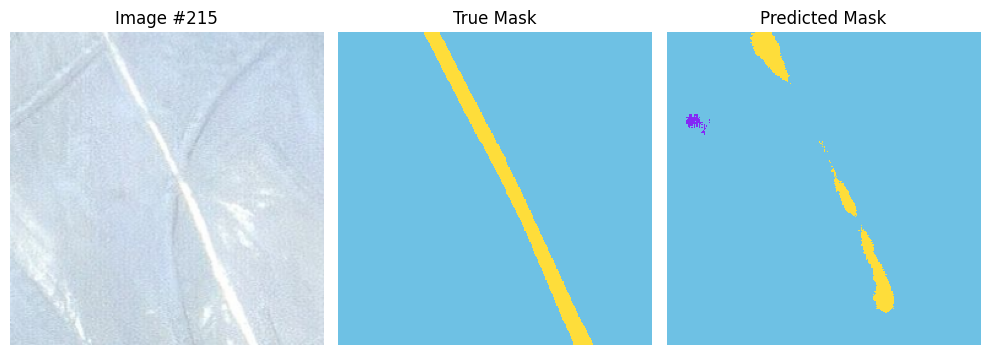

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap([
    (60/255, 16/255, 152/255),
    (132/255, 41/255, 246/255),
    (110/255, 193/255, 228/255),
    (254/255, 221/255, 58/255),
    (226/255, 169/255, 41/255),
    (155/255, 155/255, 155/255)
])

n_classes = 6

for i in range(4):
    test_image_number = random.randint(0, len(x_test) - 1)

    test_image = x_test[test_image_number]
    true_mask = np.argmax(y_test[test_image_number], axis=-1)
    predicted_mask = np.argmax(y_pred[test_image_number], axis=-1)

    plt.figure(figsize=(10, 6))
    plt.subplot(131)
    plt.imshow(test_image)
    plt.title(f'Image #{test_image_number}')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(true_mask, cmap=custom_cmap, vmin=0, vmax=n_classes-1)
    plt.title('True Mask')
    plt.axis('off')

    plt.subplot(133)
    plt.imshow(predicted_mask, cmap=custom_cmap, vmin=0, vmax=n_classes-1)
    plt.title('Predicted Mask')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

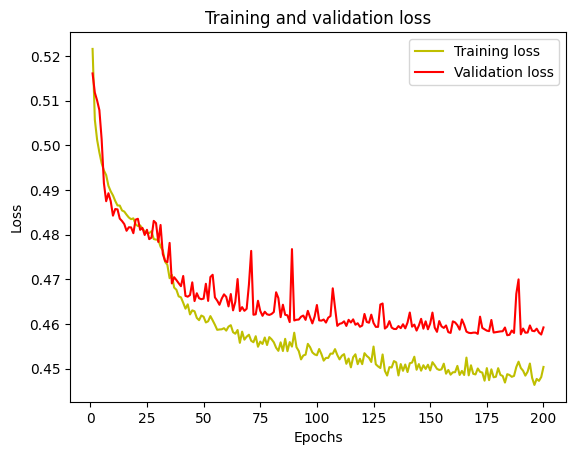

In [56]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_validation_loss.png', dpi=300)
plt.show()

In [39]:
from keras.metrics import MeanIoU
# after inference:
y_pred_argmax = np.argmax(y_pred, axis=-1)
y_true_argmax = np.argmax(y_test, axis=-1)
miou = MeanIoU(num_classes=6)
miou.update_state(y_true_argmax, y_pred_argmax)
print("Mean IoU =", float(miou.result().numpy()))

Mean IoU = 0.8021610379219055


In [40]:
print("Final training accuracy:", history.history['accuracy'][-1])
print("Final validation accuracy:", history.history['val_accuracy'][-1])

Final training accuracy: 0.9427376389503479
Final validation accuracy: 0.9203649163246155


In [41]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred_argmax = np.argmax(y_pred, axis=-1)
y_true_argmax = np.argmax(y_test, axis=-1)

class_names = ['Unlabeled', 'Building', 'Land', 'Road', 'Vegetation', 'Water']
n_classes = 6

cm = confusion_matrix(y_true_argmax.flatten(), y_pred_argmax.flatten(), labels=range(n_classes))

print("Confusion Matrix:")
print(cm)
print("-" * 30)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP

epsilon = 1e-6

per_class_iou = (TP + epsilon) / (TP + FP + FN + epsilon)
per_class_accuracy = (TP + epsilon) / (TP + FN + epsilon)
per_class_precision = (TP + epsilon) / (TP + FP + epsilon)

print("--- Per-Class Metrics (Manual Calculation) ---")
for i in range(n_classes):
    print(f"Class: {class_names[i]} (ID: {i})")
    print(f"  IoU:              {per_class_iou[i]:.4f}")
    print(f"  Accuracy (Recall): {per_class_accuracy[i]:.4f}")
    print(f"  Precision:        {per_class_precision[i]:.4f}")
    print("-" * 25)

print(f"Calculated Mean IoU (all classes): {np.mean(per_class_iou):.4f}")

Confusion Matrix:
[[   34008     2186     8711     1133     4178     1178]
 [      24  2449356   228658    19659    32803      713]
 [    1788   219661 13772198   406602   205279    49018]
 [     734    24979   291183  2042755    57378     3307]
 [       4    33678   103022    30953  2392246    28683]
 [     118     1010    64185     3020    26986  3017646]]
------------------------------
--- Per-Class Metrics (Manual Calculation) ---
Class: Unlabeled (ID: 0)
  IoU:              0.6291
  Accuracy (Recall): 0.6617
  Precision:        0.9273
-------------------------
Class: Building (ID: 1)
  IoU:              0.8130
  Accuracy (Recall): 0.8968
  Precision:        0.8969
-------------------------
Class: Land (ID: 2)
  IoU:              0.8972
  Accuracy (Recall): 0.9398
  Precision:        0.9519
-------------------------
Class: Road (ID: 3)
  IoU:              0.7089
  Accuracy (Recall): 0.8440
  Precision:        0.8158
-------------------------
Class: Vegetation (ID: 4)
  IoU:        

In [42]:
from sklearn.metrics import classification_report

print("\n--- Classification Report (from scikit-learn) ---")
report = classification_report(
    y_true_argmax.flatten(),
    y_pred_argmax.flatten(),
    target_names=class_names,
    labels=range(n_classes),
    zero_division=0
)
print(report)


--- Classification Report (from scikit-learn) ---
              precision    recall  f1-score   support

   Unlabeled       0.93      0.66      0.77     51394
    Building       0.90      0.90      0.90   2731213
        Land       0.95      0.94      0.95  14654546
        Road       0.82      0.84      0.83   2420336
  Vegetation       0.88      0.92      0.90   2588586
       Water       0.97      0.97      0.97   3112965

    accuracy                           0.93  25559040
   macro avg       0.91      0.87      0.89  25559040
weighted avg       0.93      0.93      0.93  25559040



In [43]:
#without unlabeled
import numpy as np
from sklearn.metrics import classification_report

y_pred_argmax = np.argmax(y_pred, axis=-1)
y_true_argmax = np.argmax(y_test, axis=-1)

mask = (y_true_argmax != 0)

filtered_true = y_true_argmax[mask]
filtered_pred = y_pred_argmax[mask]

filtered_class_names = ['Building', 'Land', 'Road', 'Vegetation', 'Water']
filtered_labels = [1, 2, 3, 4, 5] 

print("--- Classification Report (Without Unlabeled Class) ---")
report = classification_report(
    filtered_true,
    filtered_pred,
    target_names=filtered_class_names,
    labels=filtered_labels,
    zero_division=0
)
print(report)

--- Classification Report (Without Unlabeled Class) ---
              precision    recall  f1-score   support

    Building       0.90      0.90      0.90   2731213
        Land       0.95      0.94      0.95  14654546
        Road       0.82      0.84      0.83   2420336
  Vegetation       0.88      0.92      0.90   2588586
       Water       0.97      0.97      0.97   3112965

   micro avg       0.93      0.93      0.93  25507646
   macro avg       0.90      0.91      0.91  25507646
weighted avg       0.93      0.93      0.93  25507646



In [44]:
import numpy as np

mean_iou_filtered = np.mean(per_class_iou[1:])
mean_accuracy_filtered = np.mean(per_class_accuracy[1:]) 
mean_precision_filtered = np.mean(per_class_precision[1:])

print("--- New Macro Averages (Without Unlabeled Class) ---")
print(f"Mean IoU (Classes 1-5):        {mean_iou_filtered:.4f}")
print(f"Mean Accuracy/Recall (Classes 1-5): {mean_accuracy_filtered:.4f}")
print(f"Mean Precision (Classes 1-5):  {mean_precision_filtered:.4f}")

--- New Macro Averages (Without Unlabeled Class) ---
Mean IoU (Classes 1-5):        0.8368
Mean Accuracy/Recall (Classes 1-5): 0.9148
Mean Precision (Classes 1-5):  0.9035


In [46]:
model.save("model.keras")

In [47]:
import joblib

In [48]:
joblib.dump(model, 'model.pkl')

['model.pkl']

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

y_true_f = np.argmax(y_test, axis=-1).flatten()
y_pred_f = np.argmax(y_pred, axis=-1).flatten()

m = (y_true_f != 0)
yt = y_true_f[m]
yp = y_pred_f[m]

classes = np.unique(yt)
ious = []
for c in classes:
    tp = np.sum((yt==c)&(yp==c))
    fp = np.sum((yt!=c)&(yp==c))
    fn = np.sum((yt==c)&(yp!=c))
    ious.append(tp/(tp+fp+fn+1e-6))

mean_iou = np.mean(ious)
_, _, macro_f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
overall_acc = (yt==yp).mean()

print("Mean IoU:", round(mean_iou,4))
print("Macro F1:", round(macro_f1,4))
print("Overall Accuracy:", round(overall_acc,4))
